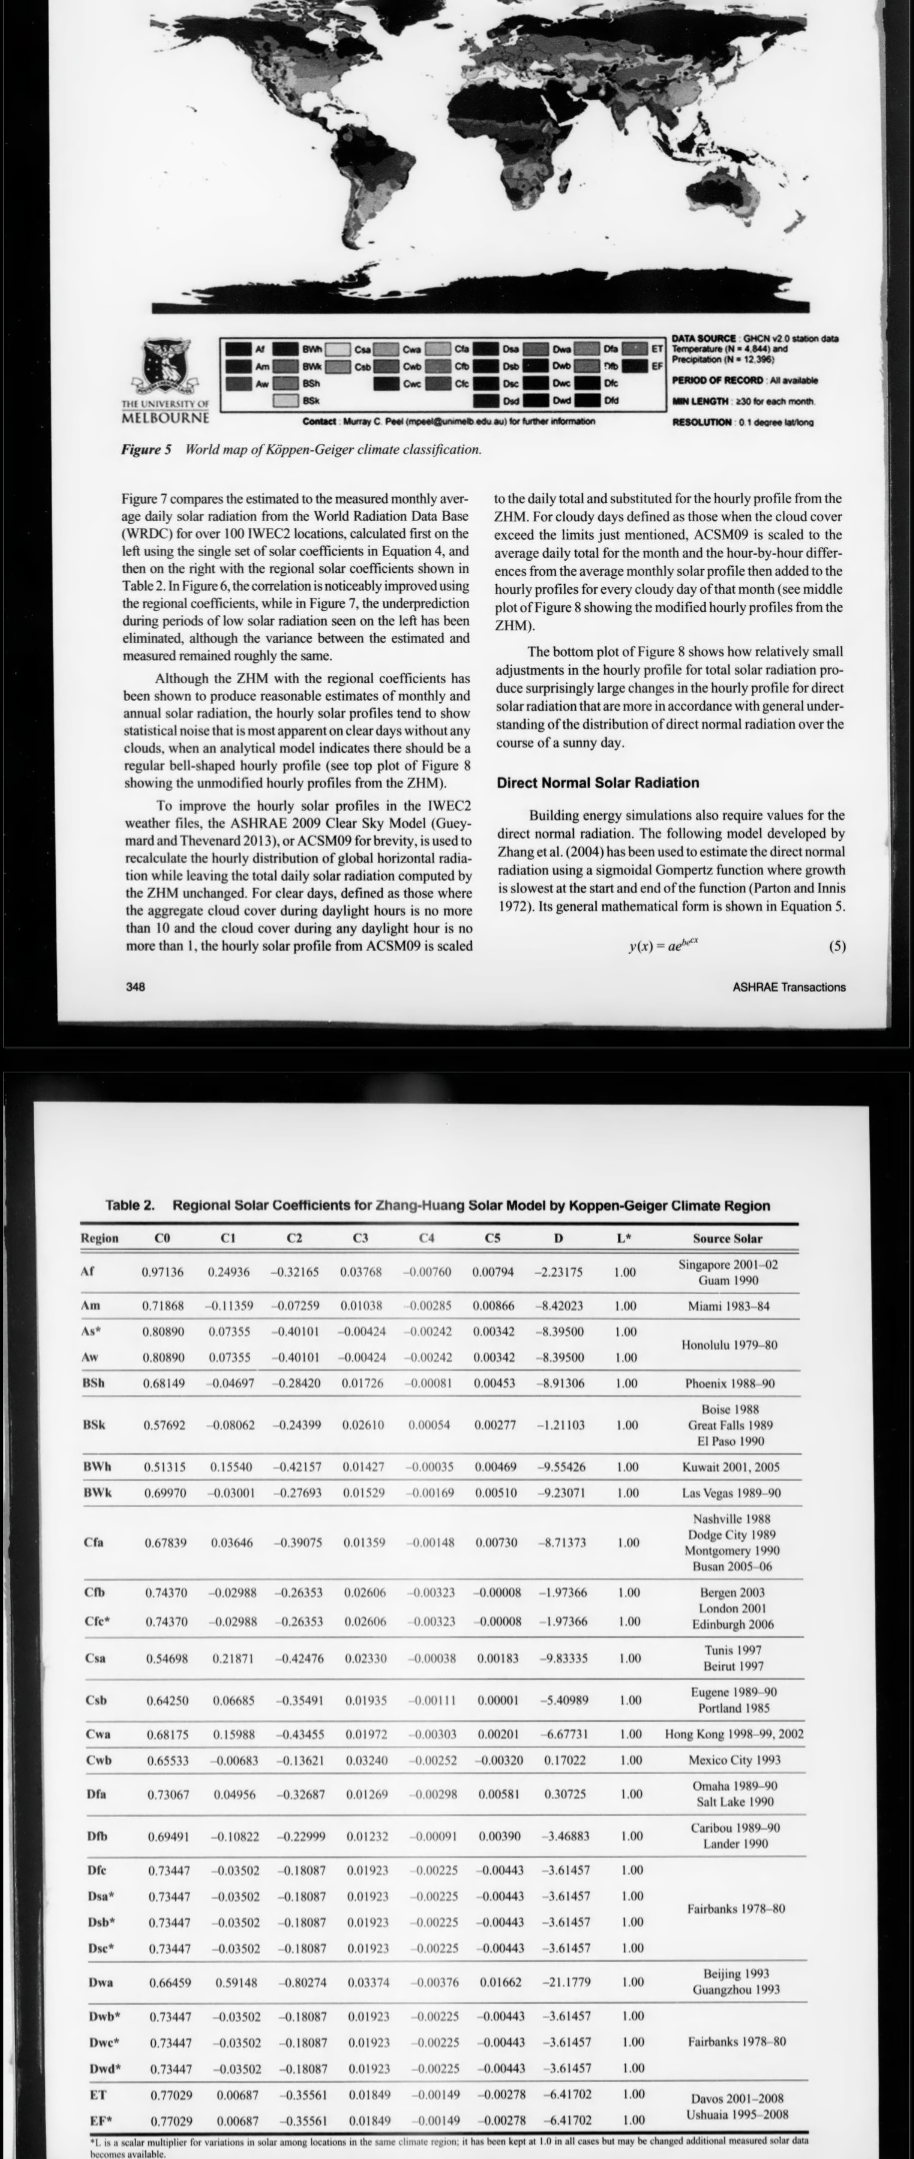

In [58]:
from pathlib import Path
from stitching import Stitcher, AffineStitcher
from PIL import Image, ImageChops
stitcher = Stitcher()

imgs_dir = Path(r"C:\Users\tgerrish\Downloads\IWEC2_Methodology")
pages_dir = imgs_dir / "pages"
pages_dir.mkdir(exist_ok=True, parents=True)

files = list(imgs_dir.glob("*.png"))
stitcher = AffineStitcher(detector="sift", confidence_threshold=0.9, crop=False)

d = {
    # 340: (0, 4),
    # 341: (7, 11),
    # 342: (12, 16),
    # 343: (17, 21),
    # 344: (22, 25),
    # 345: (26, 30),
    # 346: (31, 35),
    # 347_1: (34, 41),
    # 347_2: (34, 43),
    # 348: (34, 44),
    349_1: (40, 50),
    # 349_2: (45, 55),
    # 350: (44, 51),
    # 351: (51, 57),
    # 352: (57, 62),
    # 353: (62, 66),
    # 354: (66, 70),
    # 355: (70, -1),
}

for k, v in d.items():
    panorama = stitcher.stitch([i.as_posix() for i in files][v[0]:v[1]])
    im = Image.fromarray(panorama)
    im.save(pages_dir / f"{k:02d}.png")

im

In [64]:
#!/usr/bin/python
from PIL import Image
import os, sys
import numpy as np

files = np.sort(list(pages_dir.glob("*.png")))

MAXWIDTH = 842

def resize(fp):
    outfile = fp.parent / f"rs_{fp.stem}.png"
    im = Image.open(fp)
    s = im.size
    ratio = MAXWIDTH / s[0]
    newimg = im.resize((int(s[0]*ratio), int(s[1]*ratio)), Image.Resampling.LANCZOS)
    newimg.save(outfile)

for ff in files:
    resize(ff)

In [ ]:
# https://stackoverflow.com/questions/62103092/extract-already-know-shape-from-image

In [14]:
from PIL import Image



import cv2
import numpy as np
from os.path import basename
from glob import glob

def get_contours(img):
    # First make the image 1-bit and get contours
    imgray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    ret, thresh = cv2.threshold(imgray, 150, 255, 0)

    cv2.imwrite('thresh.jpg', thresh)
    img2, contours, hierarchy = cv2.findContours(thresh, 1, 2)

    # filter contours that are too large or small
    size = get_size(img)
    contours = [cc for cc in contours if contourOK(cc, size)]
    return contours

def get_size(img):
    ih, iw = img.shape[:2]
    return iw * ih

def contourOK(cc, size=1000000):
    x, y, w, h = cv2.boundingRect(cc)
    if w < 50 or h < 50: return False # too narrow or wide is bad
    area = cv2.contourArea(cc)
    return area < (size * 0.5) and area > 200

def find_boundaries(img, contours):
    # margin is the minimum distance from the edges of the image, as a fraction
    ih, iw = img.shape[:2]
    minx = iw
    miny = ih
    maxx = 0
    maxy = 0

    for cc in contours:
        x, y, w, h = cv2.boundingRect(cc)
        if x < minx: minx = x
        if y < miny: miny = y
        if x + w > maxx: maxx = x + w
        if y + h > maxy: maxy = y + h

    return (minx, miny, maxx, maxy)

def crop(img, boundaries):
    minx, miny, maxx, maxy = boundaries
    return img[miny:maxy, minx:maxx]

def process_image(img):
    # img = cv2.imread(fname)
    img = img.convert('RGBA')
    open_cv_image = np.array(img)
    open_cv_image = open_cv_image[:, :, ::-1].copy()
    contours = get_contours(open_cv_image)
    #cv2.drawContours(img, contours, -1, (0,255,0)) # draws contours, good for debugging
    bounds = find_boundaries(open_cv_image, contours)
    cropped = crop(open_cv_image, bounds)
    if get_size(cropped) < 400: 
        return # too small
    return cropped
    # cv2.imwrite('cropped/' + basename(fname), cropped)

process_image(Image.fromarray(panorama))

ValueError: not enough values to unpack (expected 3, got 2)